# Bike Sharing Data Analysis

### Objectif

L’objectif de ce projet est d’explorer les données horaires de location de vélos afin de comprendre les tendances de la demande, le comportement des utilisateurs et l’influence de certaines conditions météorologiques et temporelles.

Ce notebook suit une démarche simple : **exploration → préparation des données → analyse → visualisation → conclusions**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/hour.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/hour.csv'

## 1. Exploration des données

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.shape

(17379, 17)

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [ ]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 2. Préparation des données

In [ ]:
df["dteday"] = pd.to_datetime(df["dteday"] , dayfirst=False, format=None )

In [ ]:
df["dteday"].dtype

dtype('<M8[us]')

In [ ]:
df["year"] = df["dteday"].dt.year

In [ ]:
df["month_name"]=df["dteday"].dt.month_name()

In [ ]:
df["day_name"] = df["dteday"].dt.day_name()

## 3. Analyse de la demande

Cette partie cherche à identifier les périodes où les locations sont les plus importantes.

In [ ]:
df["cnt"].sum()

3292679

In [ ]:
df["cnt"].mean()

189.46308763450142

In [ ]:
df.groupby("year")["cnt"].sum().idxmax()

2012

**Résultat :** 2012 est l’année qui totalise le plus de locations dans ce dataset.

In [ ]:
df.groupby("month_name")["cnt"].sum().idxmax()

'May'

**Résultat :** mai est le mois qui totalise le plus de locations.

In [ ]:
df.groupby("hr")["cnt"].sum().idxmax()

16

**Résultat :** 16 h est l’heure qui totalise le plus de locations selon cette agrégation.

In [ ]:
df.groupby("hr")["cnt"].sum().idxmin()

**Résultat :** 4 h est l’heure qui totalise le moins de locations selon cette agrégation.

## 4. Analyse des utilisateurs

In [ ]:
df[["casual", "registered"]].sum()

casual         620017
registered    2672662
dtype: int64

In [ ]:
total_locations = df["registered"].sum() + df["casual"].sum()

pour = (df["registered"].sum() / total_locations) * 100

print(f"Part des utilisateurs registered : {pour:.2f}%")

In [ ]:
evolution = df.groupby('yr')[['casual', 'registered']].sum()
print("Volumes par année :\n", evolution)

Volumes par année :
     casual  registered
yr                    
0   247252      995851
1   372765     1676811


## 5. Influence de la météo

In [ ]:

df.groupby("weathersit")["cnt"].mean()

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64

## 6. Jours travaillés et heures de la journée

On compare la demande moyenne entre les jours travaillés et les jours non travaillés.

In [ ]:
df[df['workingday'] == 1]['cnt'].mean()

193.20775389801938

**Observation :** la demande moyenne est légèrement plus élevée les jours travaillés que les jours non travaillés.

In [ ]:
df[df['workingday'] == 0]['cnt'].mean()

181.40533188248097

In [ ]:
df.groupby(['workingday', 'hr'])['cnt'].mean().unstack(level=0)

workingday,0,1
hr,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


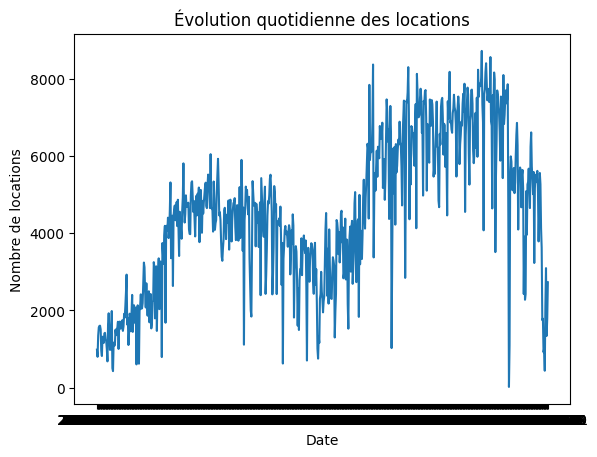

In [ ]:
daily = df.groupby("dteday")["cnt"].sum()

plt.plot(daily.index, daily.values)

plt.title("Évolution quotidienne des locations")
plt.xlabel("Date")
plt.ylabel("Nombre de locations")
plt.show()


## 7. Visualisations

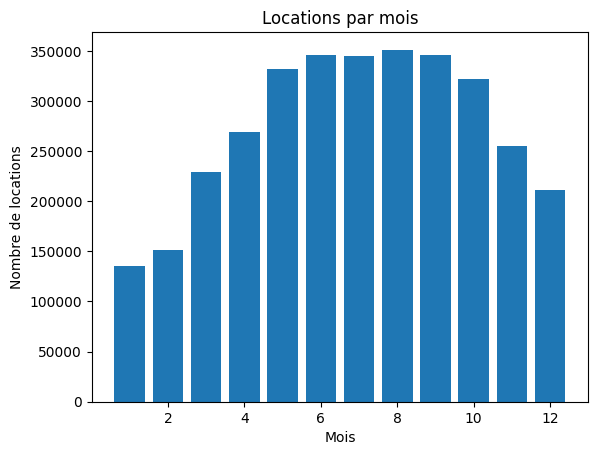

In [ ]:
monthly = df.groupby("mnth")["cnt"].sum()

plt.bar(monthly.index, monthly.values)

plt.title("Locations par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de locations")
plt.show()

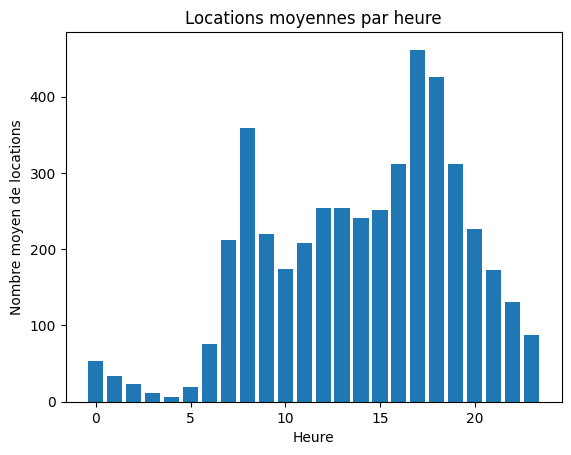

In [ ]:
hourly = df.groupby("hr")["cnt"].mean()

plt.bar(hourly.index, hourly.values)

plt.title("Locations moyennes par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de locations")
plt.show()

In [ ]:
plt.hist(df["cnt"], bins=20)
plt.title("Distribution du nombre de locations")
plt.xlabel("Nombre de locations")
plt.ylabel("Fréquence")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["cnt"])

plt.title("Température vs nombre de locations")
plt.xlabel("Température")
plt.ylabel("Nombre de locations")

plt.show()

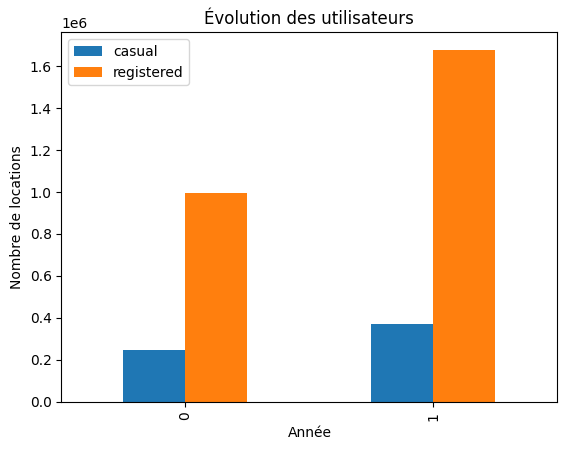

In [ ]:
evolution = df.groupby("yr")[["casual", "registered"]].sum()

evolution.plot(kind="bar")

plt.title("Évolution des utilisateurs")
plt.xlabel("Année")
plt.ylabel("Nombre de locations")
plt.show()

## 8. Statistiques avec NumPy

In [ ]:
np.mean(df['cnt'])
np.median(df['cnt'])
np.std(df['cnt'])
np.min(df['cnt'])
np.max(df['cnt'])

189.46308763450142

## 9. Conclusions

- Le dataset contient **17 379 observations et 17 colonnes**.
- Il ne contient **aucun doublon** selon le contrôle effectué.
- **2012** enregistre le plus grand volume total de locations.
- **Mai** est le mois qui totalise le plus de locations.
- L’heure **16 h** présente le plus grand volume total de locations dans l’analyse réalisée.
- Les utilisateurs `registered` représentent la majorité des locations, avec environ **81,17 %** du total.
- La demande moyenne varie selon les catégories de météo.
- Les jours travaillés ont une demande moyenne légèrement supérieure aux jours non travaillés, mais les profils horaires sont très différents.
- Les visualisations permettent de mieux observer les tendances temporelles et la relation entre la température et la demande.
